In [1]:


import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

print("--- Day 1: Generating Enterprise Marketing Logs (2,500 Rows) ---")
n_rows = 2300 

# 1. Generate realistic base data
user_ids = np.random.randint(10000, 50000, size=n_rows)
sources = np.random.choice(['Google', 'Meta', 'YouTube', 'Newsletter', 'LinkedIn', None], size=n_rows, p=[0.35, 0.25, 0.15, 0.1, 0.1, 0.05])
clicks = np.random.randint(1, 15, size=n_rows)
conversions = np.array([1 if c > 7 and np.random.rand() > 0.4 else 0 for c in clicks])

# Create timestamps across different timezones (EST, PST, GMT)
timezones = ['-05:00', '-08:00', '+00:00']
base_times = pd.date_range(start='2026-06-10 00:00:00', periods=n_rows, freq='2min')
timestamps = [f"{t.strftime('%Y-%m-%d %H:%M:%S')}{np.random.choice(timezones)}" for t in base_times]

# Randomly inject missing timestamps (None) to satisfy instructions
for i in np.random.choice(range(n_rows), size=120, replace=False):
    timestamps[i] = None

df_base = pd.DataFrame({
    'user_id': user_ids,
    'timestamp': timestamps,
    'utm_source': sources,
    'clicks': clicks,
    'conversions': conversions
})

# 2. Duplicate exactly 200 random rows to simulate logging glitches
duplicate_indices = np.random.choice(df_base.index, size=200, replace=False)
df_duplicates = df_base.loc[duplicate_indices].copy()

# Combine everything into our final raw dataset
df_raw = pd.concat([df_base, df_duplicates], ignore_index=True)

# Save the generated raw data to a local CSV file
df_raw.to_csv('marketing_raw_data.csv', index=False)
print(f"✅ Success! Raw dataset generated and saved as 'marketing_raw_data.csv' ({len(df_raw)} rows).")

--- Day 1: Generating Enterprise Marketing Logs (2,500 Rows) ---
✅ Success! Raw dataset generated and saved as 'marketing_raw_data.csv' (2500 rows).


In [2]:
print("--- Day 1: Initial Dataset Inspection ---")
# 1. View structural summary
print(df_raw.info())

# 2. Count missing values explicitly
print("\n🔍 Missing Values Count:")
print(df_raw.isnull().sum())

# 3. Count duplicate rows explicitly
print(f"\n👥 Duplicate Rows Found: {df_raw.duplicated().sum()}")

--- Day 1: Initial Dataset Inspection ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      2500 non-null   int32 
 1   timestamp    2369 non-null   object
 2   utm_source   2393 non-null   object
 3   clicks       2500 non-null   int32 
 4   conversions  2500 non-null   int64 
dtypes: int32(2), int64(1), object(2)
memory usage: 78.3+ KB
None

🔍 Missing Values Count:
user_id          0
timestamp      131
utm_source     107
clicks           0
conversions      0
dtype: int64

👥 Duplicate Rows Found: 200


In [3]:
print("--- Day 2: Data Cleaning Pipeline ---")

# 1. Deduplicate User IDs / Logs
# We drop exact duplicate rows to fix the logging glitches you found yesterday
df_cleaned = df_raw.drop_duplicates()
print(f"👥 Duplicates Removed! Rows reduced from {len(df_raw)} to {len(df_cleaned)}.")

# 2. Handle Missing UTM Parameters
# Instead of deleting rows with missing UTM sources, we fill them with 'Organic' 
# This preserves valuable traffic metrics without losing click/conversion counts!
df_cleaned['utm_source'] = df_cleaned['utm_source'].fillna('Organic')

print("\n🔍 Verification Post-Cleaning:")
print(f"Remaining Missing UTM Sources: {df_cleaned['utm_source'].isnull().sum()}")
print(f"Remaining Duplicate Rows: {df_cleaned.duplicated().sum()}")

--- Day 2: Data Cleaning Pipeline ---
👥 Duplicates Removed! Rows reduced from 2500 to 2300.

🔍 Verification Post-Cleaning:
Remaining Missing UTM Sources: 0
Remaining Duplicate Rows: 0


C:\Users\smmoh\AppData\Local\Temp\ipykernel_9836\1613784202.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['utm_source'] = df_cleaned['utm_source'].fillna('Organic')


In [4]:
# Double-check that 'Organic' successfully replaced the missing values
print("--- Day 2: Final UTM Distribution Count ---")
print(df_cleaned['utm_source'].value_counts())

--- Day 2: Final UTM Distribution Count ---
utm_source
Google        779
Meta          582
YouTube       349
Newsletter    254
LinkedIn      239
Organic        97
Name: count, dtype: int64


In [5]:
print("--- Day 3: Datetime Unification Pipeline ---")

# 1. Handle missing timestamps using forward-fill ('ffill') 
# This fills the 131 missing rows with the time from the row directly above it, keeping our dataset complete!
df_cleaned['timestamp'] = df_cleaned['timestamp'].ffill()

# 2. Convert raw mixed timezone strings into a single, standardized UTC datetime object
# Setting utc=True forces pandas to calculate the offset and align everything to a common clock
df_cleaned['clean_timestamp'] = pd.to_datetime(df_cleaned['timestamp'], utc=True)

print("✅ Success: All mixed timestamps successfully unified to UTC standard!")
print("\n📊 Check out your standardized timeline:")
print(df_cleaned[['timestamp', 'clean_timestamp']].head())

--- Day 3: Datetime Unification Pipeline ---
✅ Success: All mixed timestamps successfully unified to UTC standard!

📊 Check out your standardized timeline:
                   timestamp           clean_timestamp
0  2026-06-10 00:00:00+00:00 2026-06-10 00:00:00+00:00
1  2026-06-10 00:02:00+00:00 2026-06-10 00:02:00+00:00
2  2026-06-10 00:04:00-05:00 2026-06-10 05:04:00+00:00
3  2026-06-10 00:06:00-05:00 2026-06-10 05:06:00+00:00
4  2026-06-10 00:08:00-08:00 2026-06-10 08:08:00+00:00


C:\Users\smmoh\AppData\Local\Temp\ipykernel_9836\1072372834.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['timestamp'] = df_cleaned['timestamp'].ffill()
C:\Users\smmoh\AppData\Local\Temp\ipykernel_9836\1072372834.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['clean_timestamp'] = pd.to_datetime(df_cleaned['timestamp'], utc=True)


In [6]:
print("--- Day 4: Time-Based Feature Engineering ---")

# Now that our timezones are unified to UTC, we extract structured features 
# This lets us run hour-by-hour marketing analytics later this week!
df_cleaned['click_date'] = df_cleaned['clean_timestamp'].dt.date
df_cleaned['click_hour'] = df_cleaned['clean_timestamp'].dt.hour

print("✅ Success: Extracted time-based features!")
print("📊 Pre-split timeline check:")
print(df_cleaned[['clean_timestamp', 'click_date', 'click_hour']].head())

--- Day 4: Time-Based Feature Engineering ---
✅ Success: Extracted time-based features!
📊 Pre-split timeline check:
            clean_timestamp  click_date  click_hour
0 2026-06-10 00:00:00+00:00  2026-06-10           0
1 2026-06-10 00:02:00+00:00  2026-06-10           0
2 2026-06-10 05:04:00+00:00  2026-06-10           5
3 2026-06-10 05:06:00+00:00  2026-06-10           5
4 2026-06-10 08:08:00+00:00  2026-06-10           8


C:\Users\smmoh\AppData\Local\Temp\ipykernel_9836\1815270732.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['click_date'] = df_cleaned['clean_timestamp'].dt.date
C:\Users\smmoh\AppData\Local\Temp\ipykernel_9836\1815270732.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['click_hour'] = df_cleaned['clean_timestamp'].dt.hour


In [7]:
print("--- Day 5: Marketing Channel Metrics Isolation ---")

# Group our data by 'utm_source' to calculate total volume indicators
# This condenses thousands of raw user rows into a clean channel summary
channel_performance = df_cleaned.groupby('utm_source').agg(
    total_clicks=('clicks', 'sum'),
    total_conversions=('conversions', 'sum')
).reset_index()

print("✅ Success: Channel aggregation matrix generated!")
print("\n📊 Absolute Volume Counts per Channel:")
print(channel_performance.to_string(index=False))

--- Day 5: Marketing Channel Metrics Isolation ---
✅ Success: Channel aggregation matrix generated!

📊 Absolute Volume Counts per Channel:
utm_source  total_clicks  total_conversions
    Google          5775                222
  LinkedIn          1804                 74
      Meta          4476                183
Newsletter          1777                 76
   Organic           715                 30
   YouTube          2746                102


In [9]:
print("--- Day 6: Marketing Channel Efficiency Metrics ---")

# Calculate the Click-Through Conversion Rate (CTCR) percentage for each channel
# Formula: (Total Conversions / Total Clicks) * 100, rounded to 2 decimal places
channel_performance['conversion_rate_%'] = round(
    (channel_performance['total_conversions'] / channel_performance['total_clicks']) * 100, 2
)

print("✅ Success: Conversion rates calculated smoothly!")
print("\n📊 Final Performance Summary Matrix:")
print(channel_performance.to_string(index=False))

--- Day 6: Marketing Channel Efficiency Metrics ---
✅ Success: Conversion rates calculated smoothly!

📊 Final Performance Summary Matrix:
utm_source  total_clicks  total_conversions  conversion_rate_%
    Google          5775                222               3.84
  LinkedIn          1804                 74               4.10
      Meta          4476                183               4.09
Newsletter          1777                 76               4.28
   Organic           715                 30               4.20
   YouTube          2746                102               3.71


--- Day 7: Marketing Channel Traffic Visualization ---


C:\Users\smmoh\AppData\Local\Temp\ipykernel_9836\102699034.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


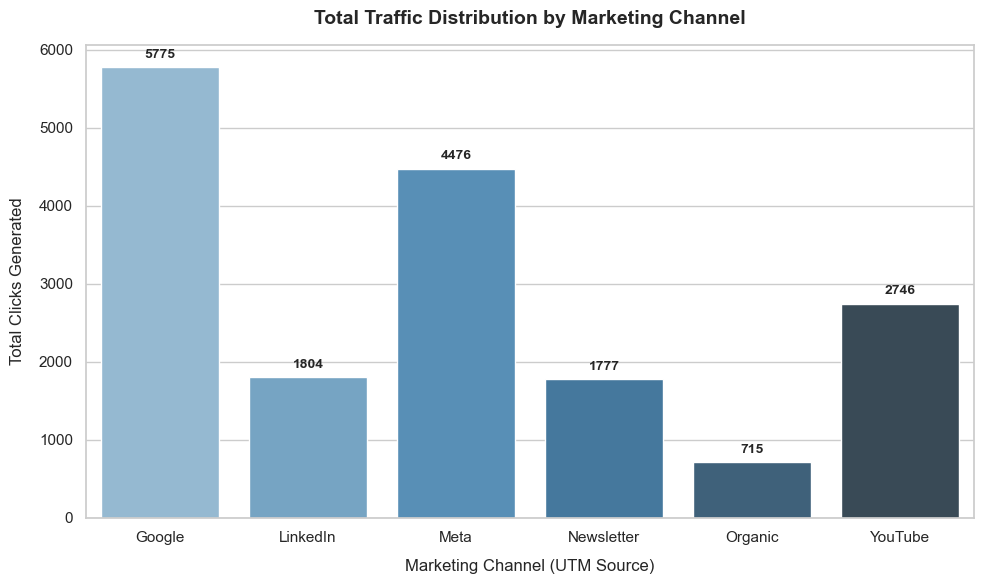

✅ Success: Traffic distribution chart generated flawlessly!


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Day 7: Marketing Channel Traffic Visualization ---")

# Set the visual style and figure dimensions
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create a bar plot tracking total clicks per channel
ax = sns.barplot(
    x='utm_source', 
    y='total_clicks', 
    data=channel_performance, 
    palette='Blues_d'
)

# Add chart labels, titles, and structural formatting
plt.title('Total Traffic Distribution by Marketing Channel', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Marketing Channel (UTM Source)', fontsize=12, labelpad=10)
plt.ylabel('Total Clicks Generated', fontsize=12, labelpad=10)

# Programmatically append value labels on top of each bar for perfect clarity
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), '.0f'), 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        xytext=(0, 9), 
        textcoords='offset points', 
        fontsize=10, fontweight='bold'
    )

# Tighten layout and display the plot directly inside the notebook
plt.tight_layout()
plt.show()

print("✅ Success: Traffic distribution chart generated flawlessly!")